In [186]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [187]:
data_dir = Path("data")
INDIR = Path("data/data_raw")
OUTDIR = Path("data/data_processed")

OUTDIR.mkdir(parents=True, exist_ok=True)

In [188]:
arquivo = INDIR / "PARTICIPANTES_2024.csv"
df = pd.read_csv(arquivo, sep=';', encoding='latin-1')

In [189]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

display(df.head())

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023
0,210062064233,2024,5,F,1,1,1,1,3,NaN,0,4314902,Porto Alegre,43,RS,F,F,C,D,4,B,C,A,C,D,C,B,B,A,B,B,B,D,A,B,B,E,A
1,210062064234,2024,11,F,1,1,1,1,10,NaN,0,4318903,São Luiz Gonzaga,43,RS,B,C,A,D,2,B,E,A,B,B,B,B,B,A,A,A,A,B,A,B,A,C,A
2,210062064235,2024,11,F,1,1,1,1,9,NaN,0,4320107,Sarandi,43,RS,H,F,F,D,5,B,J,A,C,D,B,B,C,A,B,B,B,D,B,B,A,D,A
3,210062064236,2024,3,F,1,3,1,2,0,1.0,0,4313409,Novo Hamburgo,43,RS,B,B,B,B,6,A,C,A,B,C,B,A,B,A,B,A,A,A,A,B,A,D,A
4,210062064237,2024,16,M,3,1,1,1,18,NaN,0,4309209,Gravataí,43,RS,B,B,C,C,2,A,A,A,B,C,A,A,B,A,A,A,A,B,A,B,A,B,A


In [190]:
df_clustering = df[['NU_INSCRICAO', 'TP_FAIXA_ETARIA', 'TP_SEXO', 'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'IN_TREINEIRO', 'SG_UF_PROVA', 'Q007']]

In [191]:
df_clustering.isnull().mean()*100

NU_INSCRICAO       0.0
TP_FAIXA_ETARIA    0.0
TP_SEXO            0.0
TP_ESTADO_CIVIL    0.0
TP_COR_RACA        0.0
IN_TREINEIRO       0.0
SG_UF_PROVA        0.0
Q007               0.0
dtype: float64

In [192]:
df_clustering.info()

<class 'pandas.DataFrame'>
RangeIndex: 4332944 entries, 0 to 4332943
Data columns (total 8 columns):
 #   Column           Dtype
---  ------           -----
 0   NU_INSCRICAO     int64
 1   TP_FAIXA_ETARIA  int64
 2   TP_SEXO          str  
 3   TP_ESTADO_CIVIL  int64
 4   TP_COR_RACA      int64
 5   IN_TREINEIRO     int64
 6   SG_UF_PROVA      str  
 7   Q007             str  
dtypes: int64(5), str(3)
memory usage: 264.5 MB


In [193]:
df_clustering['TP_SEXO'].value_counts()
df_clustering = df_clustering.rename(columns={'TP_SEXO': 'SEXO'})

In [194]:
faixa_etaria_map = {
    1: 16,
    2: 17,
    3: 18,
    4: 19,
    5: 20,
    6: 21,
    7: 22,
    8: 23,
    9: 24,
    10: 25,
    11: (26+30)/2,
    12: (31+35)/2,
    13: (36+40)/2,
    14: (41+45)/2,
    15: (46+50)/2,
    16: (51+55)/2,
    17: (56+60)/2,
    18: (60+80)/2,
    19: (60+80)/2,
    20: (60+80)/2
}


df_clustering = df_clustering.rename(columns={'TP_FAIXA_ETARIA': 'IDADE'})
df_clustering['IDADE'] = df_clustering['IDADE'].map(faixa_etaria_map)
df_clustering['IDADE'] = df_clustering['IDADE'].astype("Int64")

In [195]:
cor_raca_map = {
    0: "NÃO DECLARADO",
    1: "BRANCA",
    2: "PRETA",
    3: "PARDA",
    4: "AMARELA",
    5: "INDÍGENA",
    # 6: "NÃO DISPÕE DA INFORMAÇÃO" -> AGRUPADO COM 0 POR SIMPLIFICAÇÃO
    6: "NÃO DECLARADO"
}

df_clustering['TP_COR_RACA'] = df_clustering['TP_COR_RACA'].map(cor_raca_map)
df_clustering = df_clustering[df_clustering['TP_COR_RACA'] != 'NÃO DECLARADO']
df_clustering = df_clustering.rename(columns={'TP_COR_RACA': 'COR_RACA'})

In [196]:
df_clustering = df_clustering[df_clustering['IN_TREINEIRO'] != 1]
df_clustering = df_clustering.drop(columns=['IN_TREINEIRO'])

In [197]:
cor_renda_map_sm = {
    "A": 0.0,
    "B": 1.0,
    "C": 1.5,
    "D": 2.0,
    "E": 2.5,
    "F": 3.0,
    "G": 4.0,
    "H": 5.0,
    "I": 6.0,
    "J": 7.0,
    "K": 8.0,
    "L": 9.0,
    "M": 10.0,
    "N": 12.0,
    "O": 15.0,
    "P": 20.0,
    "Q": 20.0
}

df_clustering['Q007'] = df_clustering['Q007'].map(cor_renda_map_sm)
df_clustering['Q007'] = df_clustering['Q007'].astype("Float64")
df_clustering = df_clustering.rename(columns={'Q007': 'RENDA_FAMILIAR_SM'})

In [198]:
estado_civil_map = {
    0: "NAO_INFORMADO",
    1: "SOLTEIRO",
    2: "UNIAO",
    3: "DIVORCIADO",
    4: "NAO_INFORMADO" # Simplificando
}

df_clustering['TP_ESTADO_CIVIL'] = df_clustering['TP_ESTADO_CIVIL'].map(estado_civil_map)
df_clustering = df_clustering[df_clustering['TP_ESTADO_CIVIL'] != 'NAO_INFORMADO']
df_clustering = df_clustering.rename(columns={'TP_ESTADO_CIVIL': 'ESTADO_CIVIL'})

In [199]:
uf_para_regiao = {
    "AC": "NORTE", "AP": "NORTE", "AM": "NORTE", "PA": "NORTE", "RO": "NORTE", "RR": "NORTE", "TO": "NORTE",
    "AL": "NORDESTE", "BA": "NORDESTE", "CE": "NORDESTE", "MA": "NORDESTE", "PB": "NORDESTE", "PE": "NORDESTE", "PI": "NORDESTE", "RN": "NORDESTE", "SE": "NORDESTE",
    "DF": "CENTRO_OESTE", "GO": "CENTRO_OESTE", "MT": "CENTRO_OESTE", "MS": "CENTRO_OESTE",
    "ES": "SUDESTE", "MG": "SUDESTE", "RJ": "SUDESTE", "SP": "SUDESTE",
    "PR": "SUL", "RS": "SUL", "SC": "SUL"
}

df_clustering["REGIAO"] = df_clustering["SG_UF_PROVA"].map(uf_para_regiao)
df_clustering = df_clustering.rename(columns={'SG_UF_PROVA': 'UF'})

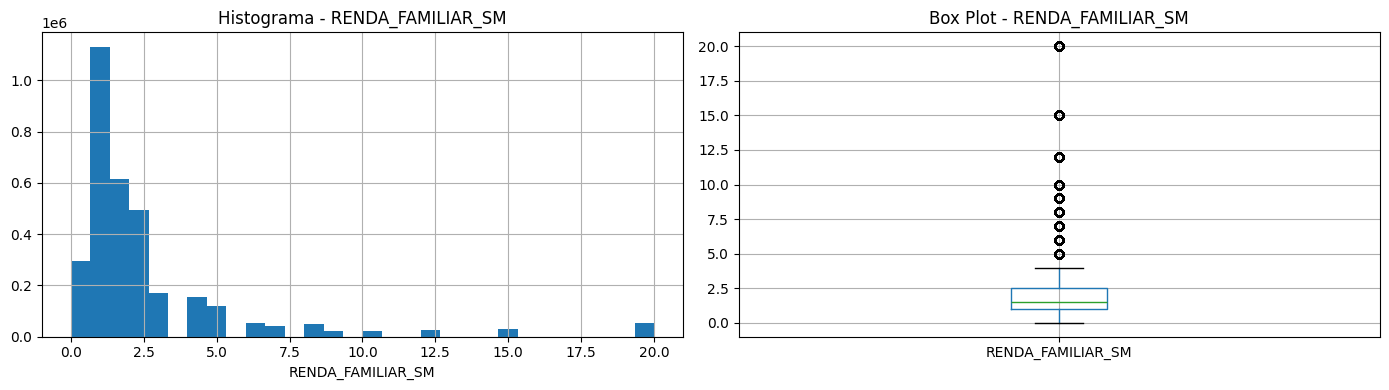

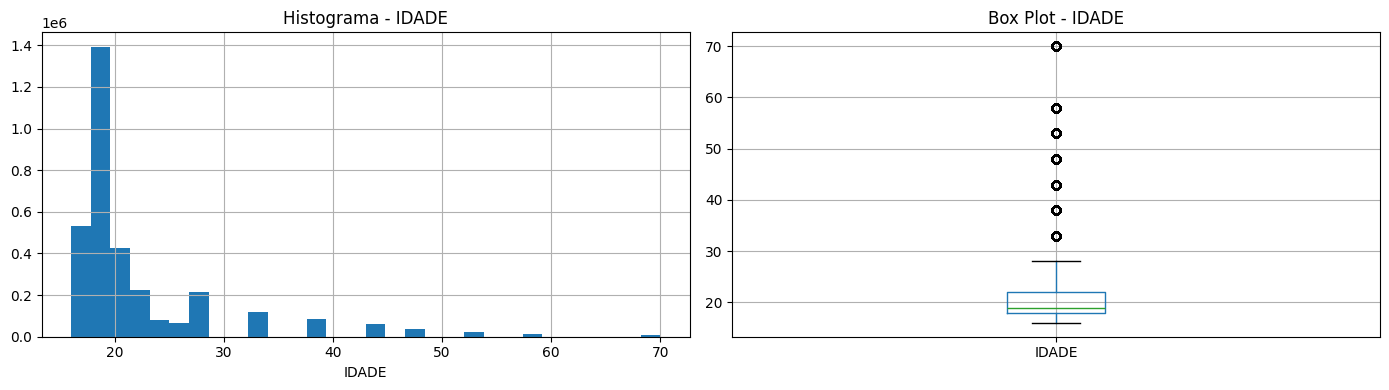

In [200]:
analise_cols = ['RENDA_FAMILIAR_SM', 'IDADE']

for col in analise_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    df_clustering[col].hist(ax=ax1, bins=30)
    ax1.set_title(f'Histograma - {col}')
    ax1.set_xlabel(col)
    
    df_clustering.boxplot(column=col, ax=ax2)
    ax2.set_title(f'Box Plot - {col}')
    
    plt.tight_layout()
    plt.show()

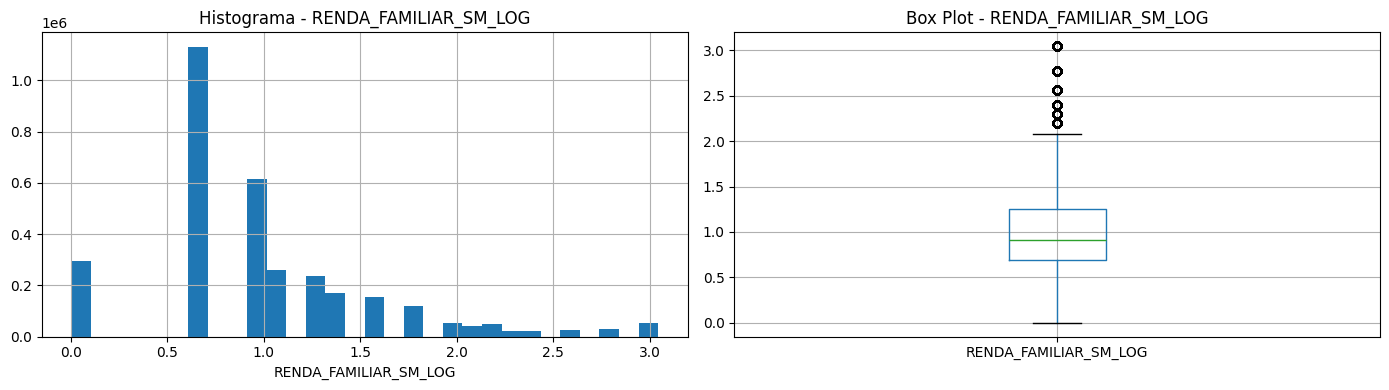

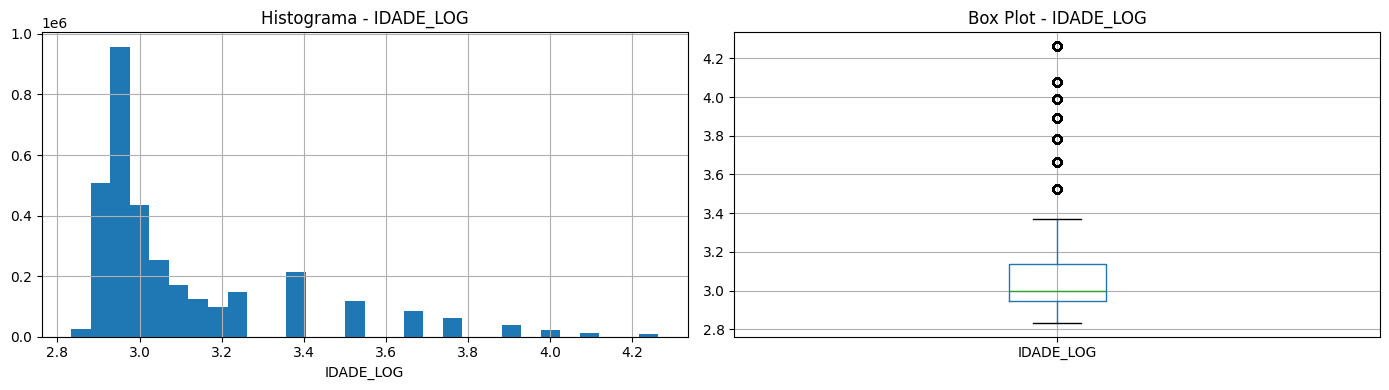

In [201]:
# TRANSFORMAÇÃO PARA ESCALA LOGARÍTMICA DE NET_SALES

df_clustering['RENDA_FAMILIAR_SM_LOG'] = np.log1p(df_clustering['RENDA_FAMILIAR_SM'])
df_clustering['IDADE_LOG'] = np.log1p(df_clustering['IDADE'])

analise_cols = ['RENDA_FAMILIAR_SM_LOG', 'IDADE_LOG']

for col in analise_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    df_clustering[col].hist(ax=ax1, bins=30)
    ax1.set_title(f'Histograma - {col}')
    ax1.set_xlabel(col)
    
    df_clustering.boxplot(column=col, ax=ax2)
    ax2.set_title(f'Box Plot - {col}')
    
    plt.tight_layout()
    plt.show()

In [202]:
# TRATAMENTO DE OUTLIERS

analise_de_outliers = ['IDADE_LOG', 'RENDA_FAMILIAR_SM_LOG']
for col in analise_de_outliers:
    Q1 = df_clustering[col].quantile(0.25)
    Q3 = df_clustering[col].quantile(0.75)
    IQR = Q3 - Q1
    df_clustering = df_clustering[(df_clustering[col] >= Q1 - 1.5*IQR) & (df_clustering[col] <= Q3 + 1.5*IQR)]

print(((df_clustering.shape[0] - df_clustering.shape[0]) / df_clustering.shape[0]) * 100)

0.0


In [203]:
df_clustering.head()

,NU_INSCRICAO,IDADE,SEXO,ESTADO_CIVIL,COR_RACA,UF,RENDA_FAMILIAR_SM,REGIAO,RENDA_FAMILIAR_SM_LOG,IDADE_LOG
0,210062064233,20,F,SOLTEIRO,BRANCA,RS,1.5,SUL,0.916291,3.044522
1,210062064234,28,F,SOLTEIRO,BRANCA,RS,2.5,SUL,1.252763,3.367296
2,210062064235,28,F,SOLTEIRO,BRANCA,RS,7.0,SUL,2.079442,3.367296
3,210062064236,18,F,SOLTEIRO,PARDA,RS,1.5,SUL,0.916291,2.944439
9,210062064308,28,F,SOLTEIRO,PARDA,RS,2.5,SUL,1.252763,3.367296


In [ ]:
X_scaled = df_clustering.copy()

df_clustering = df_clustering.drop(columns=['IDADE_LOG', 'RENDA_FAMILIAR_SM_LOG'])
X_scaled = X_scaled.drop(columns=['UF', 'NU_INSCRICAO', 'IDADE', 'RENDA_FAMILIAR_SM'])

In [205]:
X_scaled = pd.get_dummies(
    X_scaled,
    columns=['ESTADO_CIVIL', 'COR_RACA', 'SEXO', 'REGIAO']
)

scaler = StandardScaler()
X_scaled[['RENDA_FAMILIAR_SM_LOG', 'IDADE_LOG']] = scaler.fit_transform(X_scaled[['RENDA_FAMILIAR_SM_LOG', 'IDADE_LOG']])

cols_int8 = X_scaled.columns.difference(['IDADE_LOG', 'RENDA_FAMILIAR_SM_LOG'])
X_scaled[cols_int8] = X_scaled[cols_int8].astype('int8')

In [206]:
X_scaled.head()

,RENDA_FAMILIAR_SM_LOG,IDADE_LOG,ESTADO_CIVIL_DIVORCIADO,ESTADO_CIVIL_SOLTEIRO,ESTADO_CIVIL_UNIAO,COR_RACA_AMARELA,COR_RACA_BRANCA,COR_RACA_INDÍGENA,COR_RACA_PARDA,COR_RACA_PRETA,SEXO_F,SEXO_M,REGIAO_CENTRO_OESTE,REGIAO_NORDESTE,REGIAO_NORTE,REGIAO_SUDESTE,REGIAO_SUL
0,-0.006023,0.151242,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1
1,0.723128,2.529550,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1
2,2.514581,2.529550,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1
3,-0.006023,-0.586208,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1
9,0.723128,2.529550,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1


In [207]:
caminho_modelo = OUTDIR / "PARTICIPANTES_SIMPLIFICADO_TRATADO_MODELO.csv"
X_scaled.to_csv(caminho_modelo, index=False)

caminho_tratado = OUTDIR / "PARTICIPANTES_SIMPLIFICADO_TRATADO.csv"
df_clustering.to_csv(caminho_tratado, index=False)